### Подключаем пакет

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
# подмена агента для обращения к странице
url = 'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'
pd.read_html(url, storage_options={"User-Agent": "Mozilla/5.0"})

[                                                   0  \
 0  Historical logarithmic graph of the DJIA from ...   
 1                                         Foundation   
 2                                           Operator   
 3                                          Exchanges   
 4                                     Trading symbol   
 5                                       Constituents   
 6                                               Type   
 7                                         Market cap   
 8                                   Weighting method   
 9                                            Website   
 
                                                    1  
 0  Historical logarithmic graph of the DJIA from ...  
 1  February 16, 1885; 141 years ago (as DJA)[1] M...  
 2                              S&P Dow Jones Indices  
 3                      New York Stock ExchangeNasdaq  
 4                                  ^DJI$INDU.DJIDJIA  
 5                                 

## Диверсификация портфеля
### Загрузка данных

In [3]:
# Импортируем перечень бумаг 
import pandas as pd
url= 'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'
# методом тыка находим [1]
df = pd.read_html(url, storage_options={"User-Agent": "Mozilla/5.0"})[1]
df.head()


,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,2.17%
1,American Express,NYSE,AXP,Financials,1982-08-30,NaN,4.31%
2,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.14%
3,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.99%
4,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,2.92%


In [4]:
#Выгружаем тикера и названия компаний
names=df[['Symbol','Company']]
symbol=names['Symbol'].values
full_name=names['Company'].values
print(symbol)
print(full_name)

['MMM' 'AXP' 'AMGN' 'AMZN' 'AAPL' 'BA' 'CAT' 'CVX' 'CSCO' 'KO' 'DIS' 'GS'
 'HD' 'HON' 'IBM' 'JNJ' 'JPM' 'MCD' 'MRK' 'MSFT' 'NKE' 'NVDA' 'PG' 'CRM'
 'SHW' 'TRV' 'UNH' 'VZ' 'V' 'WMT']
['3M' 'American Express' 'Amgen' 'Amazon' 'Apple' 'Boeing' 'Caterpillar'
 'Chevron' 'Cisco' 'Coca-Cola' 'Disney' 'Goldman Sachs' 'Home Depot'
 'Honeywell' 'IBM' 'Johnson & Johnson' 'JPMorgan Chase' "McDonald's"
 'Merck' 'Microsoft' 'Nike' 'Nvidia' 'Procter & Gamble' 'Salesforce'
 'Sherwin-Williams' 'Travelers Companies, Inc.' 'UnitedHealth Group'
 'Verizon' 'Visa' 'Walmart']


In [5]:
df.groupby('Exchange')['Symbol'].count()

Exchange
NASDAQ     8
NYSE      22
Name: Symbol, dtype: int64

In [6]:
# pip install yfinance     # установить
# pip install yfinance -U  # обновить

# ВАЖНО ПЕРЕЗАПУСТИТЬ ЯДРО

In [7]:
import yfinance as yf
import datetime

start = datetime.datetime(2020, 6, 1)
end = datetime.datetime(2021, 2, 28)

data = yf.download(list(symbol), start=start, end=end)['Close']
data

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-06-01,77.977806,189.950714,123.552002,89.966751,151.389999,107.844185,174.242905,39.067245,72.180962,116.037384,...,174.155090,91.695419,8.771855,101.525017,184.578308,96.369370,276.473846,186.479813,39.760197,38.307350
2020-06-02,78.338806,187.280289,123.620499,92.124084,153.309998,110.368042,172.138474,39.565071,73.658974,116.017853,...,176.136475,92.800819,8.790782,102.226387,189.220779,98.002747,276.817261,188.408386,40.202137,38.301167
2020-06-03,78.770073,185.003342,123.919998,98.010307,173.160004,113.742058,172.889343,39.607254,75.595924,119.368927,...,176.565079,95.905228,8.735251,102.633362,188.285934,101.066467,275.949707,188.897705,40.508652,38.155926
2020-06-04,78.091698,184.902893,123.029999,99.070351,184.300003,115.415688,169.381989,39.539768,74.895836,120.844200,...,174.240814,93.298271,8.736248,100.485962,182.264954,104.183121,269.379669,185.798553,40.786644,37.735649
2020-06-05,80.315804,188.912659,124.150002,102.036720,205.429993,120.928703,171.792679,40.358242,78.419693,121.948189,...,178.317795,94.615578,8.889218,102.460182,185.475082,109.798409,281.823822,191.526718,41.157299,37.565689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-02-22,122.723434,197.851257,159.037003,127.969543,212.880005,198.872818,238.057495,39.307690,79.896675,187.348053,...,225.026337,126.432022,14.314715,111.576767,225.429428,133.255325,299.668365,200.799118,41.563126,42.881447
2021-02-23,122.587082,198.697479,159.725006,128.901413,212.119995,200.806244,232.811279,39.376904,80.903595,192.555435,...,223.836472,125.932472,14.101578,112.405342,221.599274,134.571045,301.378723,204.452271,41.990154,42.190052
2021-02-24,122.090332,196.586243,157.976501,131.678268,229.339996,202.894730,237.583313,39.575920,83.891884,192.965759,...,225.064713,125.488419,14.457560,112.528732,216.967468,136.039932,303.848267,211.508026,42.056427,41.486210


In [8]:
price = data

In [9]:
# дропнем колонки со слишком большим процентом пропусков
price = price.dropna( thresh = 0.91*len(price.index) , axis='columns')
price

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-06-01,77.977806,189.950714,123.552002,89.966751,151.389999,107.844185,174.242905,39.067245,72.180962,116.037384,...,174.155090,91.695419,8.771855,101.525017,184.578308,96.369370,276.473846,186.479813,39.760197,38.307350
2020-06-02,78.338806,187.280289,123.620499,92.124084,153.309998,110.368042,172.138474,39.565071,73.658974,116.017853,...,176.136475,92.800819,8.790782,102.226387,189.220779,98.002747,276.817261,188.408386,40.202137,38.301167
2020-06-03,78.770073,185.003342,123.919998,98.010307,173.160004,113.742058,172.889343,39.607254,75.595924,119.368927,...,176.565079,95.905228,8.735251,102.633362,188.285934,101.066467,275.949707,188.897705,40.508652,38.155926
2020-06-04,78.091698,184.902893,123.029999,99.070351,184.300003,115.415688,169.381989,39.539768,74.895836,120.844200,...,174.240814,93.298271,8.736248,100.485962,182.264954,104.183121,269.379669,185.798553,40.786644,37.735649
2020-06-05,80.315804,188.912659,124.150002,102.036720,205.429993,120.928703,171.792679,40.358242,78.419693,121.948189,...,178.317795,94.615578,8.889218,102.460182,185.475082,109.798409,281.823822,191.526718,41.157299,37.565689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-02-22,122.723434,197.851257,159.037003,127.969543,212.880005,198.872818,238.057495,39.307690,79.896675,187.348053,...,225.026337,126.432022,14.314715,111.576767,225.429428,133.255325,299.668365,200.799118,41.563126,42.881447
2021-02-23,122.587082,198.697479,159.725006,128.901413,212.119995,200.806244,232.811279,39.376904,80.903595,192.555435,...,223.836472,125.932472,14.101578,112.405342,221.599274,134.571045,301.378723,204.452271,41.990154,42.190052
2021-02-24,122.090332,196.586243,157.976501,131.678268,229.339996,202.894730,237.583313,39.575920,83.891884,192.965759,...,225.064713,125.488419,14.457560,112.528732,216.967468,136.039932,303.848267,211.508026,42.056427,41.486210


In [10]:
result_corr = price.corr()
display(result_corr.head())
np.fill_diagonal(result_corr.values,0.)
result_corr.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.107876,0.824848,0.669825,0.409270,0.815281,0.646796,-0.046019,0.052185,0.788305,...,0.852626,0.848927,0.894699,0.675310,0.880277,0.682591,0.765092,0.663092,0.497556,0.817031
AMGN,0.107876,1.000000,0.353199,-0.184146,-0.259941,-0.129822,0.087677,0.090566,-0.109942,-0.110706,...,0.206503,-0.193939,0.041980,0.004618,-0.028536,-0.198645,-0.131912,0.012869,-0.110547,-0.034407
AMZN,0.824848,0.353199,1.000000,0.280924,0.059548,0.511226,0.695161,-0.196228,-0.232172,0.429968,...,0.781824,0.544454,0.807361,0.728915,0.705334,0.325675,0.508275,0.475791,0.428765,0.699664
AXP,0.669825,-0.184146,0.280924,1.000000,0.827452,0.903792,0.286674,0.352950,0.606095,0.924524,...,0.649046,0.807380,0.596920,0.193494,0.622617,0.911616,0.739448,0.735379,0.325659,0.579203
BA,0.409270,-0.259941,0.059548,0.827452,1.000000,0.628049,-0.063643,0.576184,0.755801,0.753755,...,0.412543,0.553836,0.247684,-0.055135,0.333275,0.793063,0.580484,0.615638,0.204432,0.352137


Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000000,0.107876,0.824848,0.669825,0.409270,0.815281,0.646796,-0.046019,0.052185,0.788305,...,0.852626,0.848927,0.894699,0.675310,0.880277,0.682591,0.765092,0.663092,0.497556,0.817031
AMGN,0.107876,0.000000,0.353199,-0.184146,-0.259941,-0.129822,0.087677,0.090566,-0.109942,-0.110706,...,0.206503,-0.193939,0.041980,0.004618,-0.028536,-0.198645,-0.131912,0.012869,-0.110547,-0.034407
AMZN,0.824848,0.353199,0.000000,0.280924,0.059548,0.511226,0.695161,-0.196228,-0.232172,0.429968,...,0.781824,0.544454,0.807361,0.728915,0.705334,0.325675,0.508275,0.475791,0.428765,0.699664
AXP,0.669825,-0.184146,0.280924,0.000000,0.827452,0.903792,0.286674,0.352950,0.606095,0.924524,...,0.649046,0.807380,0.596920,0.193494,0.622617,0.911616,0.739448,0.735379,0.325659,0.579203
BA,0.409270,-0.259941,0.059548,0.827452,0.000000,0.628049,-0.063643,0.576184,0.755801,0.753755,...,0.412543,0.553836,0.247684,-0.055135,0.333275,0.793063,0.580484,0.615638,0.204432,0.352137


In [11]:
result=(abs(result_corr)>=0.8).astype(int)
#result=(result_corr>=0.9).astype(int)
result.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0,0,1,0,0,1,0,0,0,0,...,1,1,1,0,1,0,0,0,0,1
AMGN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMZN,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
AXP,0,0,0,0,1,1,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0
BA,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
import matplotlib.pyplot as plt
import networkx as nx

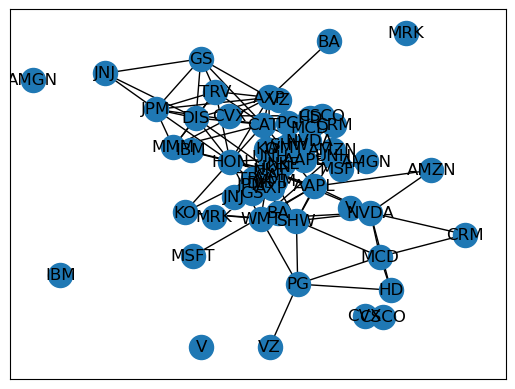

In [13]:
A=result.values
G=nx.from_numpy_array(A)
mapping=dict(zip(G.nodes(),result.index))

G1=nx.relabel_nodes(G,mapping)

nx.draw_networkx(G1)
nx.draw_networkx(G1,pos=nx.kamada_kawai_layout(G1))
plt.show()

In [14]:
clique=list(nx.find_cliques(G1))
print(clique)
max_clique=max(clique,key=len)
print()
print("максимальная ",max_clique)

[['AMGN'], ['CRM', 'MCD', 'NVDA'], ['NVDA', 'AAPL', 'WMT', 'NKE', 'SHW'], ['NVDA', 'AAPL', 'AMZN'], ['NVDA', 'MCD', 'HD'], ['NVDA', 'MCD', 'SHW'], ['V'], ['CVX', 'CSCO'], ['HON', 'NKE', 'WMT', 'SHW', 'AAPL'], ['HON', 'NKE', 'WMT', 'SHW', 'KO'], ['HON', 'NKE', 'WMT', 'SHW', 'UNH'], ['HON', 'NKE', 'CAT', 'AAPL'], ['HON', 'NKE', 'CAT', 'MMM', 'DIS', 'AXP'], ['HON', 'NKE', 'CAT', 'UNH'], ['HON', 'TRV', 'JPM', 'DIS', 'MMM', 'AXP', 'CAT'], ['MSFT', 'AAPL'], ['GS', 'JPM', 'DIS', 'TRV', 'AXP', 'CAT'], ['GS', 'JPM', 'DIS', 'JNJ'], ['MCD', 'PG', 'HD'], ['MCD', 'PG', 'SHW'], ['IBM'], ['PG', 'WMT', 'SHW'], ['PG', 'VZ'], ['BA', 'AXP'], ['MRK']]

максимальная  ['HON', 'TRV', 'JPM', 'DIS', 'MMM', 'AXP', 'CAT']


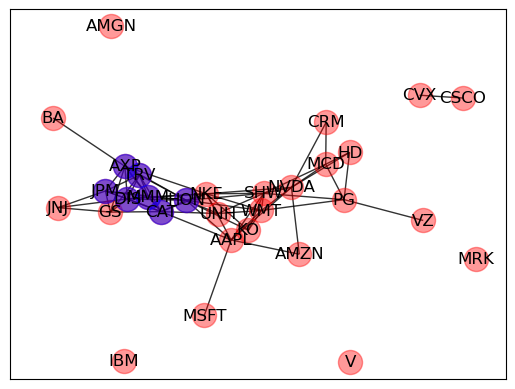

In [15]:
pos = nx.spring_layout(G1,dim=2,k=0.5)
nx.draw_networkx_nodes(G1,pos,node_color='r',alpha=0.4)
nx.draw_networkx_nodes(G1,pos,nodelist=max_clique,node_color='b',alpha=0.5)
nx.draw_networkx_edges(G1,pos,width=1.0,alpha=0.8)
nx.draw_networkx_labels(G1,pos)
plt.show()


In [16]:
# Имена бумаг в клике
max_clique_name=names.loc[names['Symbol'].isin(max_clique)]
display(max_clique_name)
# Только имена бумаг
print(max_clique_name['Company'].values)

,Symbol,Company
0,MMM,3M
1,AXP,American Express
6,CAT,Caterpillar
10,DIS,Disney
13,HON,Honeywell
16,JPM,JPMorgan Chase
25,TRV,"Travelers Companies, Inc."


['3M' 'American Express' 'Caterpillar' 'Disney' 'Honeywell'
 'JPMorgan Chase' 'Travelers Companies, Inc.']


In [17]:
no_max_clique_name=names.loc[~names['Symbol'].isin(max_clique)]
no_max_clique_name

,Symbol,Company
2,AMGN,Amgen
3,AMZN,Amazon
4,AAPL,Apple
5,BA,Boeing
7,CVX,Chevron
8,CSCO,Cisco
9,KO,Coca-Cola
11,GS,Goldman Sachs
12,HD,Home Depot
14,IBM,IBM


In [18]:
df=pd.DataFrame(price, columns=max_clique_name['Symbol'].values)
display(df.head(3))
display(df.shape)
display(df.describe())
df = df.pct_change().fillna(0).cumsum()
display(df.head())

,MMM,AXP,CAT,DIS,HON,JPM,TRV
Date,,,,,,,
2020-06-01,105.823608,89.966751,107.844185,116.037384,122.532051,84.592018,96.369370
2020-06-02,107.224792,92.124084,110.368042,116.017853,124.351013,84.875145,98.002747
2020-06-03,109.653091,98.010307,113.742058,119.368927,128.542191,89.456490,101.066467


(188, 7)

,MMM,AXP,CAT,DIS,HON,JPM,TRV
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,114.321600,101.568260,144.879450,138.289378,150.123480,96.931428,112.137268
std,6.134940,11.753308,23.642668,24.533504,21.343377,15.084487,11.917704
min,102.307030,84.602180,107.844185,106.589867,115.851387,79.075089,96.212776
25%,109.680935,90.978420,124.350061,119.596081,132.076088,85.193274,101.693209
50%,114.103645,97.860043,141.039200,127.604988,144.100952,88.761047,106.837944
75%,119.396927,111.646593,162.696453,166.586983,172.417908,106.768803,123.042889
max,129.220901,131.678268,202.894730,192.965759,181.774292,134.964813,136.039932


,MMM,AXP,CAT,DIS,HON,JPM,TRV
Date,,,,,,,
2020-06-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-06-02,0.013241,0.023979,0.023403,-0.000168,0.014845,0.003347,0.016949
2020-06-03,0.035888,0.087874,0.053973,0.028716,0.048549,0.057324,0.048211
2020-06-04,0.044199,0.098689,0.068688,0.041075,0.065243,0.078136,0.079048
2020-06-05,0.074098,0.128631,0.116454,0.050210,0.100263,0.123138,0.132947


<Figure size 300x300 with 0 Axes>

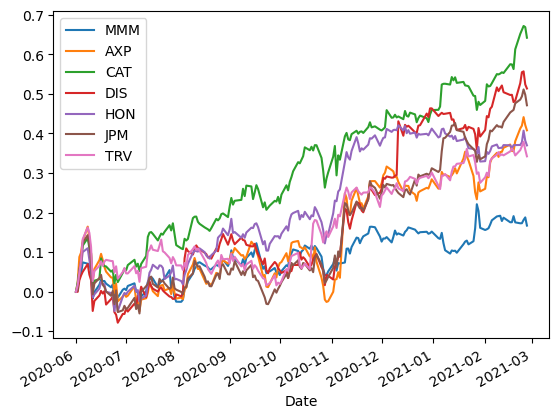

In [19]:
fig = plt.figure(figsize=(3, 3));
df.plot();
plt.show();

In [20]:
# pip install pyvis

In [21]:
from pyvis.network import Network
net = Network(notebook=True, cdn_resources='remote')
net.from_nx(G1)
net.show("example.html")

example.html


In [22]:
from pyvis.network import Network
net = Network(notebook=True, cdn_resources='remote')

colours = []

for node in G1.nodes: 
    if node in max_clique:
        net.add_node(node, color='red')  # меняем цвет для узлов в максимальной клике
    else:
        net.add_node(node)

for e in G1.edges:
    if e in nx.complete_graph(max_clique).edges:  # если ребро чать клики меняем цвет
        color = 'red'
        width = 4
    else:
        color = 'black'
        width = 2
    net.add_edge(e[0], e[1], color=color, width=width)

net.edges
net.show("01.html")    

01.html


In [23]:
net.add_edge("AAPL", "AMZN", color='red', width=4)
net.add_edge("AMZN", "AAPL", color='red', width=4)
net.add_edge("AAPL", "BA", color='red', width=4)
net.edges

[{'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'AMZN'},
 {'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'CAT'},
 {'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'HON'},
 {'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'MSFT'},
 {'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'NKE'},
 {'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'NVDA'},
 {'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'SHW'},
 {'color': 'black', 'width': 2, 'from': 'AAPL', 'to': 'WMT'},
 {'color': 'black', 'width': 2, 'from': 'AMZN', 'to': 'NVDA'},
 {'color': 'black', 'width': 2, 'from': 'AXP', 'to': 'BA'},
 {'color': 'red', 'width': 4, 'from': 'AXP', 'to': 'CAT'},
 {'color': 'red', 'width': 4, 'from': 'AXP', 'to': 'DIS'},
 {'color': 'black', 'width': 2, 'from': 'AXP', 'to': 'GS'},
 {'color': 'red', 'width': 4, 'from': 'AXP', 'to': 'HON'},
 {'color': 'red', 'width': 4, 'from': 'AXP', 'to': 'JPM'},
 {'color': 'red', 'width': 4, 'from': 'AXP', 'to': 'MMM'},
 {'color': 'black', 'wi

In [24]:
mapping[0]

'AAPL'